# APS 1 — Análise Exploratória de Dados (EDA)

In [3]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [4]:
# fetch dataset
adult = fetch_ucirepo(id=2)

In [5]:
# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# dataframe final para EDA
df = pd.concat([X, y], axis=1)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
df.shape

(48842, 15)

In [7]:
df["income"].value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

Identificamos uma inconsistência na variável alvo: o target deveria ser binário (`<=50K` e `>50K`), mas aparecem quatro rótulos devido ao ponto final em parte dos registros. A seguir, faremos a padronização desses valores.

In [8]:
# tratando a coluna do target para remover inconsistência
df["income"] = df["income"].replace({"<=50K.": "<=50K", ">50K.": ">50K"})

#EXPLICITANDO A QT DE INSTÂNCIAS
income_counts = df["income"].value_counts()
print(income_counts)
print(f"\nSoma total: {income_counts.sum()}")

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Soma total: 48842


A variável alvo foi padronizada. Durante a exploração das variáveis explicativas, novos tratamentos de qualidade de dados serão aplicados quando necessário.

In [9]:
### Verificando e informando quantidade de valores faltantes nas features (considerando '?' e NaN)
## OBS: valor absoluto e porcentual 

features_df = df.drop(columns=["income"]).copy()

is_question_mark = features_df.apply(
    lambda col: col.astype(str).str.strip().eq("?") if col.dtype == "object" else pd.Series(False, index=col.index)
)
is_nan = features_df.isna()

missing_mask = is_question_mark | is_nan
missing_counts = missing_mask.sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

if missing_counts.empty:
    print("Nenhuma feature com valores faltantes ('?' ou NaN).")
else:
    missing_summary = pd.DataFrame({
        "missing_count": missing_counts,
        "missing_pct": (missing_counts / len(features_df) * 100).round(2)
    })
    display(missing_summary)

,missing_count,missing_pct
occupation,2809,5.75
workclass,2799,5.73
native-country,857,1.75


## Visão geral da base
A base possui 15 variáveis preditoras (além do target) e aproximadamente 48 mil instâncias.

### Verificando os tipos de dados

In [10]:
df.dtypes.astype(str).sort_values()

age                int64
fnlwgt             int64
education-num      int64
capital-gain       int64
capital-loss       int64
hours-per-week     int64
workclass         object
education         object
marital-status    object
occupation        object
relationship      object
race              object
sex               object
native-country    object
income            object
dtype: object

Com a verificação dos tipos de dados acima é possível identificar quais variáveis são **numéricas**
(`int64`, `float64`) e quais são **categóricas** (`object` - armazenando valores `str`). Essa distinção é importante para definir como cada variável será analisada ou transformada nas próximas etapas.

## Classificação das variáveis

### Variáveis quantitativas

#### Discretas
- **age**: idade
- **education-num**: grau de educação (no formato numérico)
- **hours-per-week**: horas trabalhadas por semana

#### Contínuas
- **fnlwgt**: peso amostral
- **capital-gain**: ganho de capital
- **capital-loss**: perda de capital

### Variáveis qualitativas

#### Categóricas nominais
- **workclass**: tipo de vínculo de trabalho
- **marital-status**: estado civil
- **occupation**: ocupação
- **relationship**: relação familiar
- **race**: raça
- **sex**: sexo
- **native-country**: país de origem
- **income**: faixa de renda (target binário)

#### Categórica ordinal
- **education**: grau de educação

In [11]:
columns_to_remove = [
    "hours-per-week",
    "capital-loss",
    "capital-gain",
    "fnlwgt",
    "education",
]

df = df.drop(columns=columns_to_remove, errors="ignore")

print("Features removidas:", columns_to_remove)
df.head()

Features removidas: ['hours-per-week', 'capital-loss', 'capital-gain', 'fnlwgt', 'education']


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


Removemos `hours-per-week`, `capital-loss`, `capital-gain`, `fnlwgt` e `education` antes da modelagem. 

- `hours-per-week`: distribuição muito concentrada, com baixo ganho analítico nesta etapa.
- `capital-loss` e `capital-gain`: grande concentração de valores em zero (reduzindo sua utilidade na exploratória isolada).
- `fnlwgt`: peso amostral com pouca interpretação direta para o problema.
- `education`: redundante com `education-num`.

## Preparação para análise exploratória
Nesta etapa, dividimos a base em treino e teste para realizar a EDA apenas no conjunto de treino, evitando uso indevido de informações do conjunto de teste.



## Análise univariada

In [12]:
X = df.drop('income', axis=1).copy()
y = df['income'].copy() #target

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

### Estatísticas e distribuições das variáveis
A seguir, analisamos medidas-resumo, histogramas e boxplots para entender tendência central, dispersão e possíveis outliers.

In [14]:
X_train.select_dtypes(include=['number']).agg([
    "mean",
    "median",
    "std",
    "min",
    "max",
    lambda x: x.quantile(0.75) - x.quantile(0.25)
])

,age,education-num
mean,38.632662,10.077675
median,37.000000,10.000000
std,13.737816,2.565268
min,17.000000,1.000000
max,90.000000,16.000000
<lambda>,20.000000,3.000000


In [15]:
y_train.value_counts()

income
<=50K    29741
>50K      9332
Name: count, dtype: int64

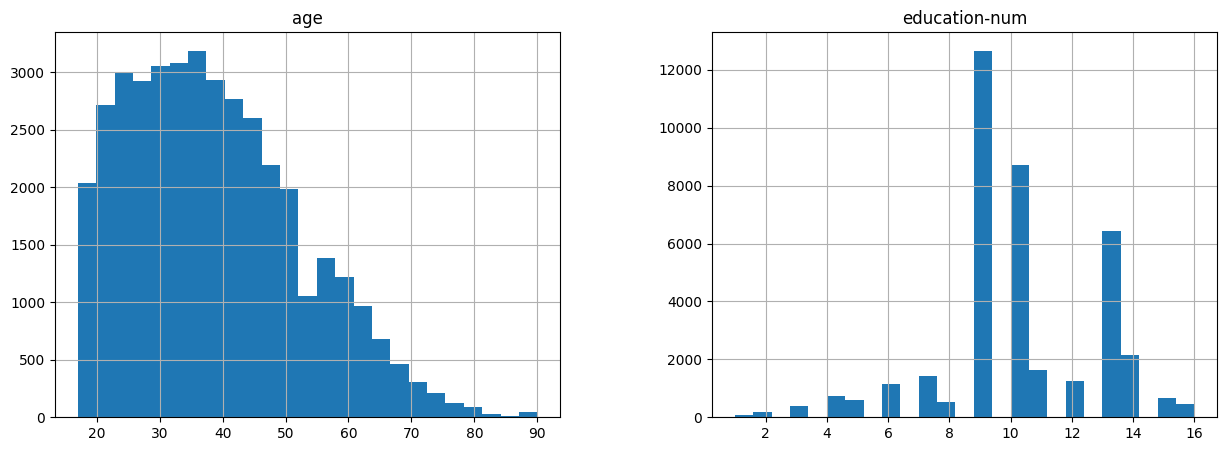

In [16]:
X_train.select_dtypes(include=['number']).hist(
    bins = 25,
    figsize = (15, 5)
)

plt.show()

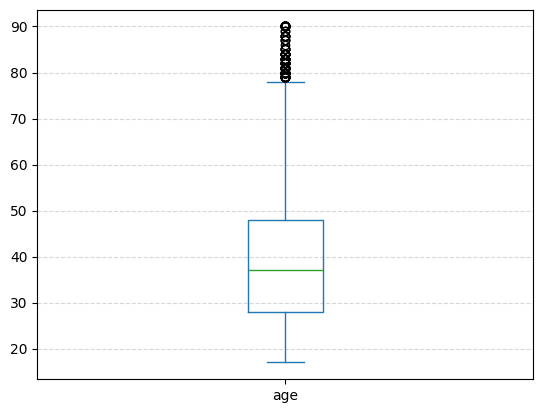

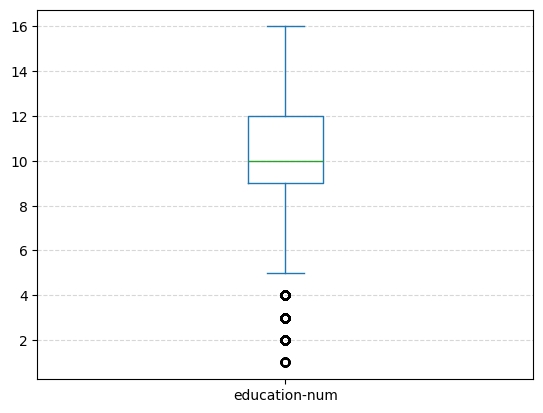

In [17]:
X_train["age"].plot.box()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

X_train["education-num"].plot.box()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

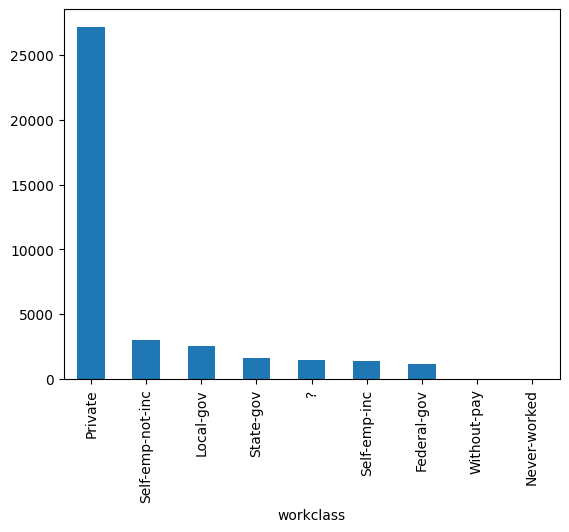

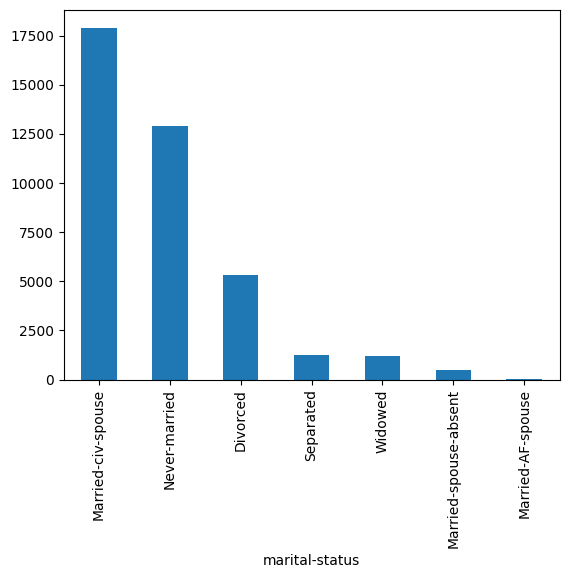

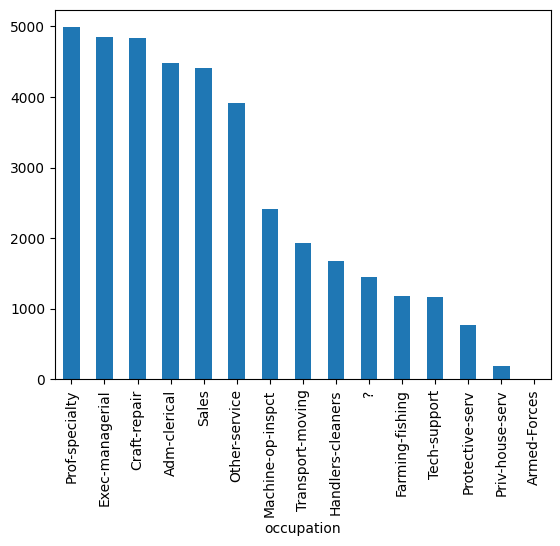

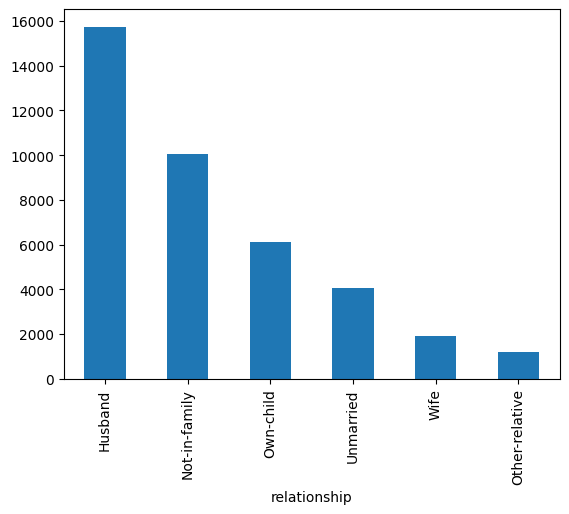

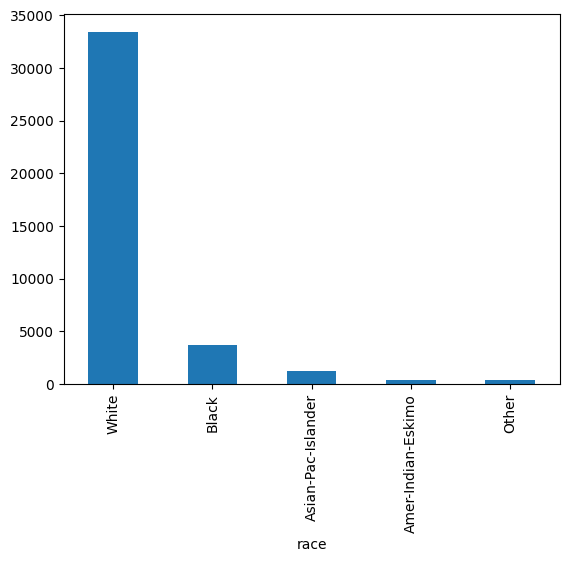

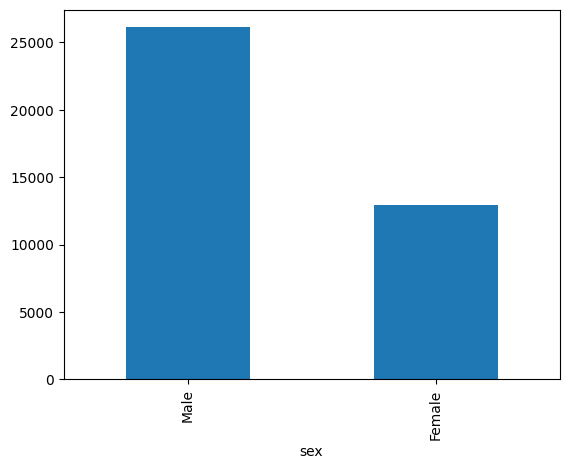

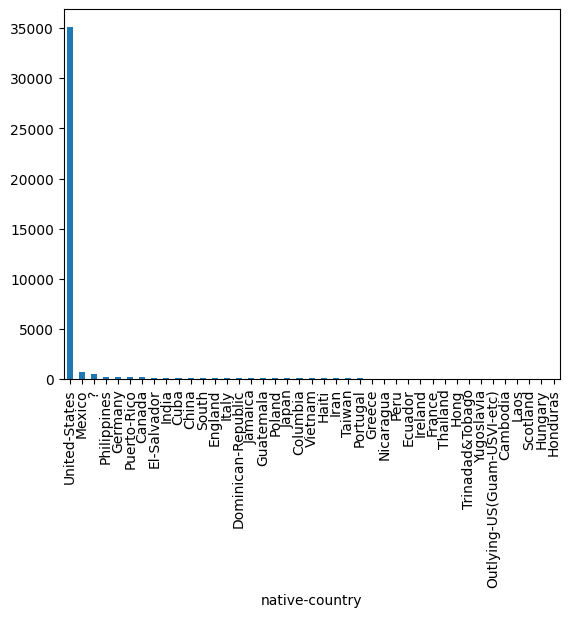

In [18]:
X_train["workclass"].value_counts().plot.bar()
plt.show()

X_train["marital-status"].value_counts().plot.bar()
plt.show()

X_train["occupation"].value_counts().plot.bar()
plt.show()

X_train["relationship"].value_counts().plot.bar()
plt.show()

X_train["race"].value_counts().plot.bar()
plt.show()

X_train["sex"].value_counts().plot.bar()
plt.show()

X_train["native-country"].value_counts().plot.bar()
plt.show()


## Principais achados da análise univariada

Com base nos gráficos e estatísticas, observamos os seguintes pontos:

- **age**: maior concentração entre 30 e 50 anos.
- **education-num**: poucos outliers e concentração em torno de 10 a 12 anos.
- **workclass** e **occupation**: presença de categoria sem identificação explícita (`?`), indicando necessidade de tratamento.
- **race**: predominância da categoria *White*.
- **sex**: predominância do sexo masculino.
- **native-country**: maioria concentrada em *United-States*, com possíveis efeitos relevantes para categorias minoritárias.

## Análise bivariada

### Relações entre variáveis numéricas

In [19]:
df_corr = X_train.select_dtypes(include=["number"]).copy()

corr = df_corr.corr().round(3)

corr

,age,education-num
age,1.000,0.031
education-num,0.031,1.000


### Relações entre variáveis categóricas e o target

In [20]:
# Separando colunas numéricas e categóricas para análise posterior
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

In [21]:
df_cat_target = X_train[cat_cols].copy()
df_cat_target["income"] = y_train.values

In [22]:
for col in cat_cols:
    print(f"\n{'='*70}\nVariável: {col}\n{'='*70}")
    
    tabela_contagem = pd.crosstab(df_cat_target[col], df_cat_target["income"])
    tabela_contagem["Total"] = tabela_contagem.sum(axis=1)
    
    tabela_prop = pd.crosstab(
        df_cat_target[col],
        df_cat_target["income"],
        normalize="index"
    ).round(3)
    
    # total em % do total geral de instâncias
    total_geral = len(df_cat_target)
    proporcao_total = (tabela_contagem["Total"] / total_geral * 100).round(2)
    tabela_prop["Total (%)"] = proporcao_total

    print("Tabela de contingência (contagem):")
    display(tabela_contagem)

    print("Tabela de contingência (proporção por categoria):")
    display(tabela_prop)


Variável: workclass
Tabela de contingência (contagem):


income,<=50K,>50K,Total
workclass,,,
?,1302,148,1450
Federal-gov,686,446,1132
Local-gov,1774,735,2509
Never-worked,9,0,9
Private,21256,5921,27177
Self-emp-inc,608,770,1378
Self-emp-not-inc,2215,819,3034
State-gov,1166,429,1595
Without-pay,15,2,17


Tabela de contingência (proporção por categoria):


income,<=50K,>50K,Total (%)
workclass,,,
?,0.898,0.102,3.71
Federal-gov,0.606,0.394,2.90
Local-gov,0.707,0.293,6.42
Never-worked,1.000,0.000,0.02
Private,0.782,0.218,69.55
Self-emp-inc,0.441,0.559,3.53
Self-emp-not-inc,0.730,0.270,7.76
State-gov,0.731,0.269,4.08
Without-pay,0.882,0.118,0.04



Variável: marital-status
Tabela de contingência (contagem):


...

income,<=50K,>50K,Total (%)
sex,,,
Female,0.892,0.108,33.17
Male,0.696,0.304,66.83



Variável: native-country
Tabela de contingência (contagem):


income,<=50K,>50K,Total
native-country,,,
?,344,121,465
Cambodia,14,5,19
Canada,105,46,151
China,68,28,96
Columbia,63,1,64
Cuba,86,24,110
Dominican-Republic,78,4,82
Ecuador,32,5,37
El-Salvador,109,10,119


Tabela de contingência (proporção por categoria):


income,<=50K,>50K,Total (%)
native-country,,,
?,0.740,0.260,1.19
Cambodia,0.737,0.263,0.05
Canada,0.695,0.305,0.39
China,0.708,0.292,0.25
Columbia,0.984,0.016,0.16
Cuba,0.782,0.218,0.28
Dominican-Republic,0.951,0.049,0.21
Ecuador,0.865,0.135,0.09
El-Salvador,0.916,0.084,0.30


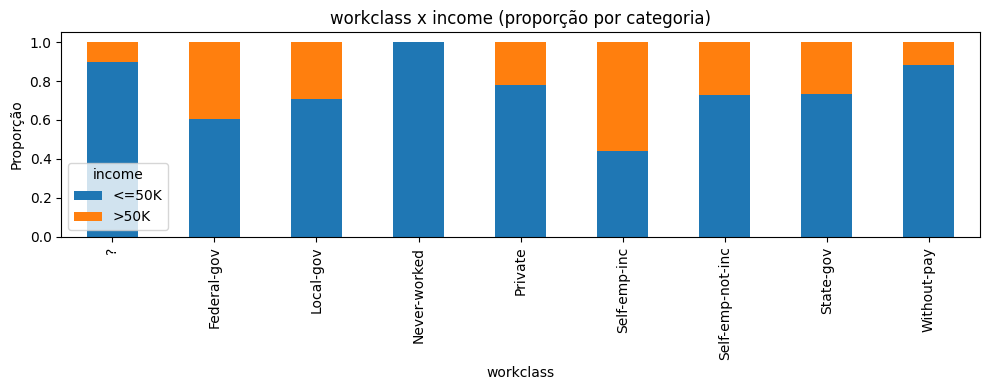

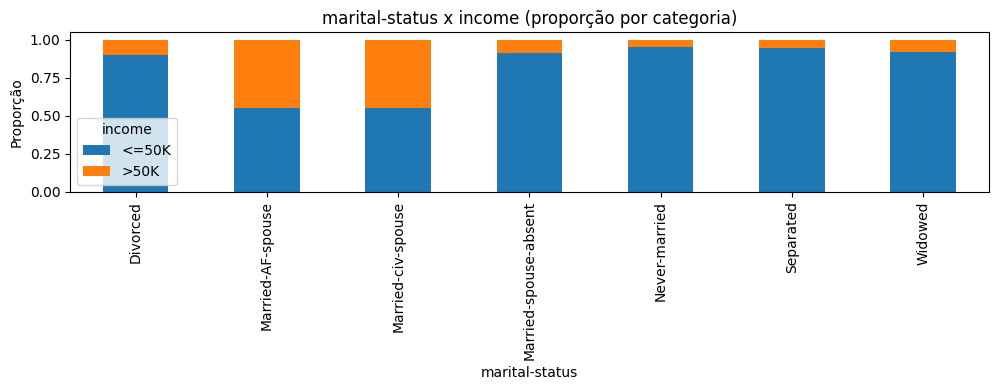

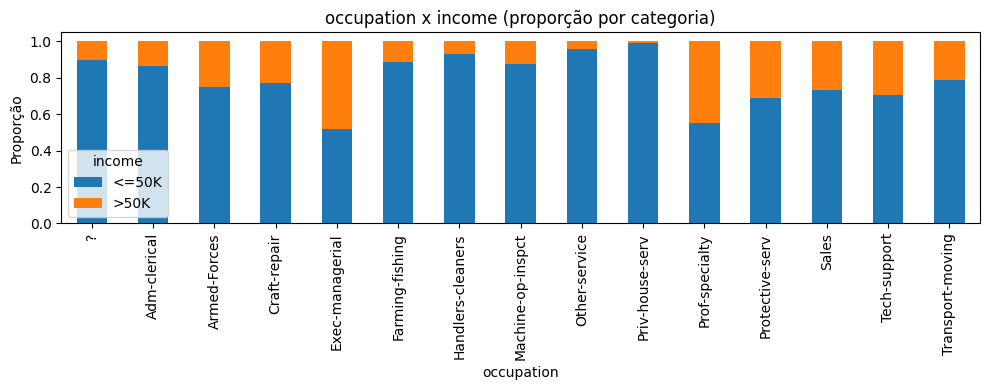

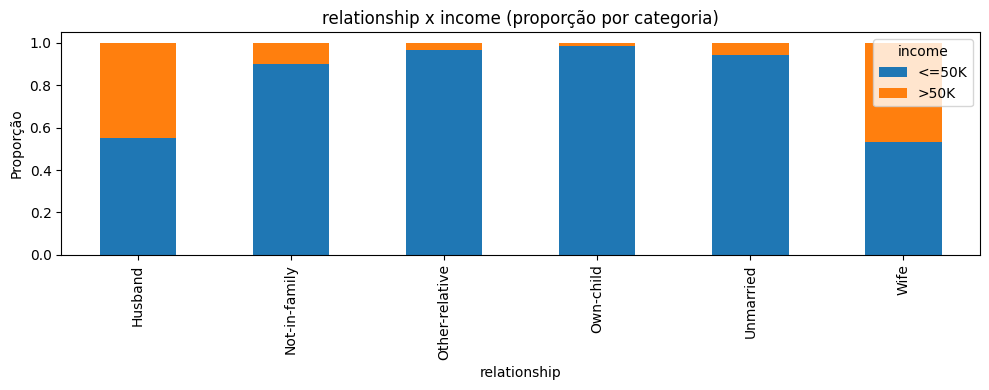

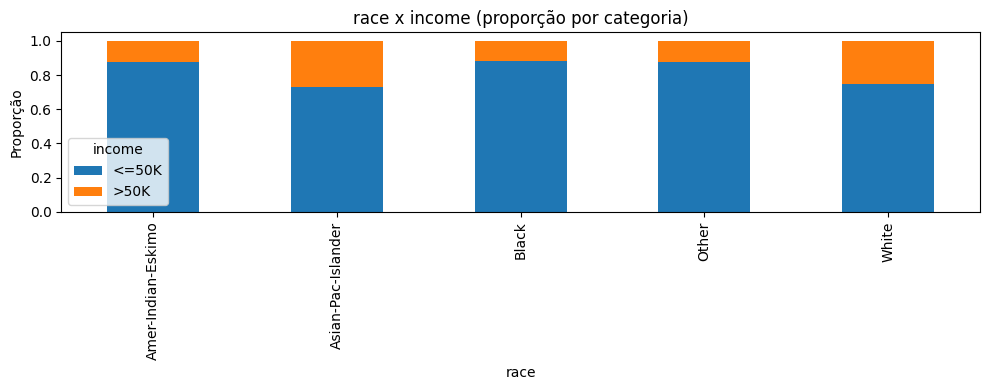

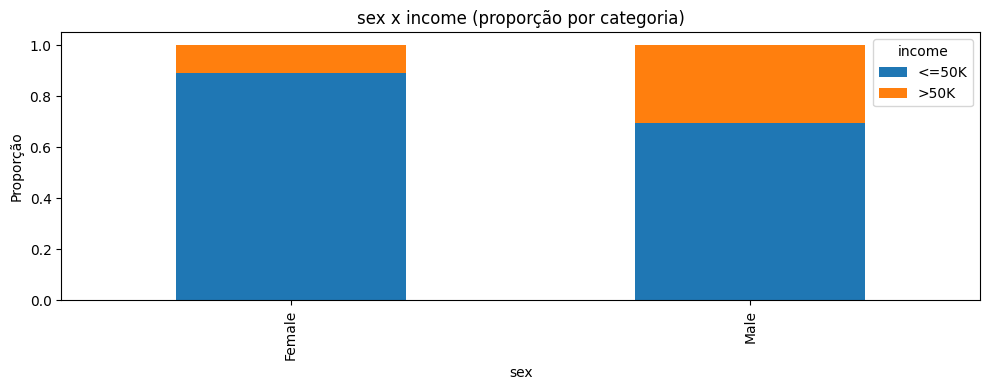

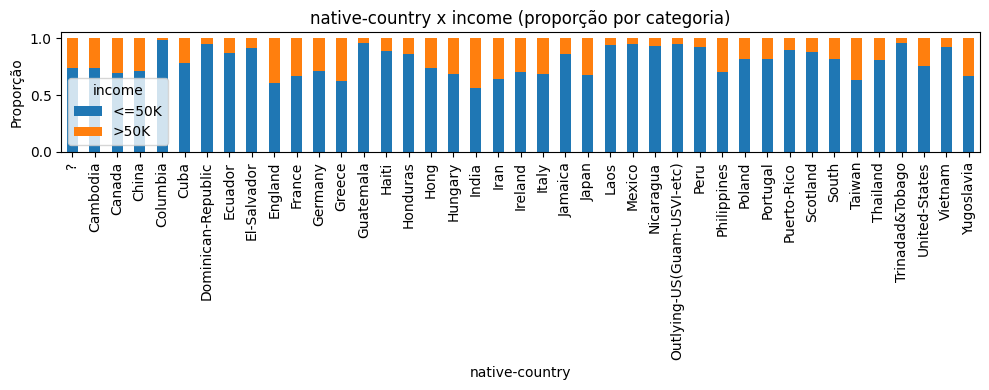

In [23]:
for col in cat_cols:
    tabela_prop = pd.crosstab(
        df_cat_target[col],
        df_cat_target["income"],
        normalize="index"
    )

    tabela_prop.plot(kind="bar", stacked=True, figsize=(10, 4))
    plt.title(f"{col} x income (proporção por categoria)")
    plt.xlabel(col)
    plt.ylabel("Proporção")
    plt.legend(title="income")
    plt.tight_layout()
    plt.show()

Nota-se uma forte evidência de undersampling nesta amostra de dados. A grande maioria dos dados concentra-se em <50K, o que faz sentido. Esta característica deste database não será tratada ainda nesta etapa do projeto.

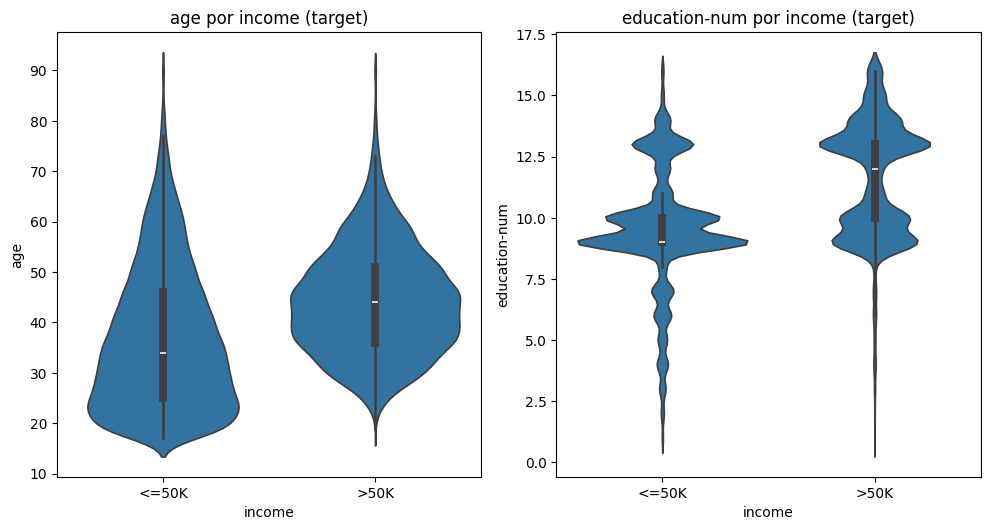

In [24]:
df_train_with_target = X_train.copy()
df_train_with_target["income"] = y_train.values

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, num_col in enumerate(num_cols):
    sns.violinplot(x="income", y=num_col, data=df_train_with_target, ax=axes[idx])
    axes[idx].set_title(f"{num_col} por income (target)")
    axes[idx].set_xlabel("income")

for idx in range(len(num_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()



In [25]:
# Remover outliers das variáveis numéricas em X_train (método IQR)

# calcular Q1, Q3 e IQR
Q1 = X_train[num_cols].quantile(0.25)
Q3 = X_train[num_cols].quantile(0.75)
IQR = Q3 - Q1

# máscara de outliers (True onde for outlier) por coluna
outlier_mask = (X_train[num_cols] < (Q1 - 1.5 * IQR)) | (X_train[num_cols] > (Q3 + 1.5 * IQR))

# manter apenas linhas que NÃO sejam outlier em nenhuma coluna numérica
rows_keep = ~outlier_mask.any(axis=1)
print(f'Instâncias originais em X_train: {len(X_train)}')

# aplicar a filtragem mantendo alinhamento entre X_train e y_train
X_train = X_train[rows_keep].reset_index(drop=True)
y_train = y_train[rows_keep].reset_index(drop=True)
print(f'Instâncias após remoção de outliers: {len(X_train)}')

Instâncias originais em X_train: 39073
Instâncias após remoção de outliers: 37533


In [35]:
# Substituir '?' por NaN para o SimpleImputer funcionar
X_train = X_train.replace("?", np.nan)
X_test = X_test.replace("?", np.nan)


print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# Colunas numericas: imputar + escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Numéricas: ['age', 'education-num']
Categóricas: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [36]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numeric_transformer, num_cols),
        ('categorical', categorical_transformer, cat_cols)
    ]
)

In [38]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   KNeighborsClassifier(n_neighbors=8))
])

In [39]:
# Treinamento
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_test)

# Avaliação
acc = accuracy_score(y_test, y_pred)

print("\nResultados no conjunto de teste:")
print(f"  Acurácia   = {acc:.3f}")
print("\nPredições vs Real:")
print("Predito:  ", y_pred.tolist())
print("Real:     ", y_test.tolist())


Resultados no conjunto de teste:
  Acurácia   = 0.822

Predições vs Real:
Predito:   ['<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '<=50K', '>50K', '<=50K', '<=50K', '>50K', '<=50K', '>50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '>50K', '<=50K', '<=50K', '<=50K', '>50K', '<=50K', '<=50K', '>50K', '<=50K', '<=50K', '>50K', '>50K

In [40]:
# Busca simples pelo melhor número de neighbors (k) — testando k de 1 a 20
k_values = range(1, 20)
scores = {}
for k in k_values:
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', KNeighborsClassifier(n_neighbors=k))])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    scores[k] = accuracy_score(y_test, y_pred)

# Encontrando o melhor k
best_k = max(scores, key=scores.get)
print(f'Best k = {best_k}  —  Acurácia = {scores[best_k]:.3f}')

# Treinando modelo final com o best_k
model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', KNeighborsClassifier(n_neighbors=best_k))])
model.fit(X_train, y_train)
y_pred_final = model.predict(X_test)
print(f'Acurácia do modelo final (k={best_k}): {accuracy_score(y_test, y_pred_final):.3f}')

Best k = 18  —  Acurácia = 0.828
Acurácia do modelo final (k=18): 0.828


## Redução de Dimensionalidade

In [50]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

/Users/guedes/Documents/Insper/Aulas26/MachineLearning/aulasMachineLearning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Preparação dos dados para redução de dimensionalidade

Utilizamos o `preprocessor` já definido (imputação + escalonamento para numéricas e imputação + one-hot para categóricas) para transformar `X_train`. Para visualização, usamos uma amostra de até 5 000 instâncias, pois t-SNE e UMAP são computacionalmente custosos.

In [51]:
# Transformar X_train com o preprocessor já ajustado
X_train_prep = preprocessor.fit_transform(X_train)

# Converter target para numérico para colorir os gráficos
y_train_num = np.where(y_train == ">50K", 1, 0)

# Amostragem para t-SNE e UMAP (limitar a 5000 para performance)
max_sample = 5000
n_samples = min(max_sample, X_train_prep.shape[0])
rng = np.random.RandomState(42)
idx = rng.choice(X_train_prep.shape[0], size=n_samples, replace=False)
X_small = X_train_prep[idx]
y_small = y_train_num[idx]

print(f"Shape dos dados pré-processados: {X_train_prep.shape}")
print(f"Amostra para visualização: {n_samples} instâncias")

Shape dos dados pré-processados: (37533, 84)
Amostra para visualização: 5000 instâncias


### PCA — Análise de Componentes Principais

PCA identifica as direções de maior variância nos dados (autovetores da matriz de covariância) e projeta os pontos nessas direções. É uma técnica linear, rápida e determinística. Primeiro analisamos a variância explicada acumulada para entender quantas componentes capturam a informação relevante e, em seguida, projetamos em 2D.

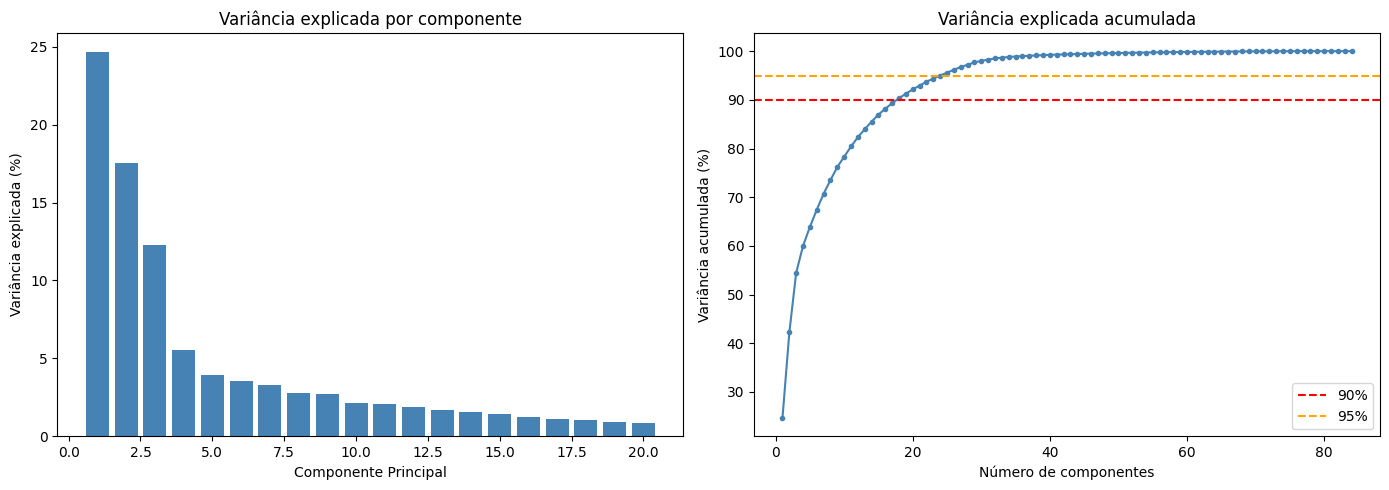

Componentes para 90% da variância: 18
Componentes para 95% da variância: 25
Variância explicada pelas 2 primeiras: 42.21%


In [52]:
# PCA com todas as componentes para analisar variância explicada
pca_full = PCA(random_state=42)
pca_full.fit(X_train_prep)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variância individual por componente (top 20)
n_show = min(20, len(var_exp))
axes[0].bar(range(1, n_show + 1), var_exp[:n_show] * 100, color="steelblue")
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Variância explicada (%)")
axes[0].set_title("Variância explicada por componente")

# Variância acumulada
axes[1].plot(range(1, len(var_acum) + 1), var_acum * 100, marker="o", markersize=3, color="steelblue")
axes[1].axhline(y=90, color="red", linestyle="--", label="90%")
axes[1].axhline(y=95, color="orange", linestyle="--", label="95%")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Variância acumulada (%)")
axes[1].set_title("Variância explicada acumulada")
axes[1].legend()

plt.tight_layout()
plt.show()

# Quantas componentes para 90% e 95%
n90 = np.argmax(var_acum >= 0.90) + 1
n95 = np.argmax(var_acum >= 0.95) + 1
print(f"Componentes para 90% da variância: {n90}")
print(f"Componentes para 95% da variância: {n95}")
print(f"Variância explicada pelas 2 primeiras: {var_acum[1]*100:.2f}%")

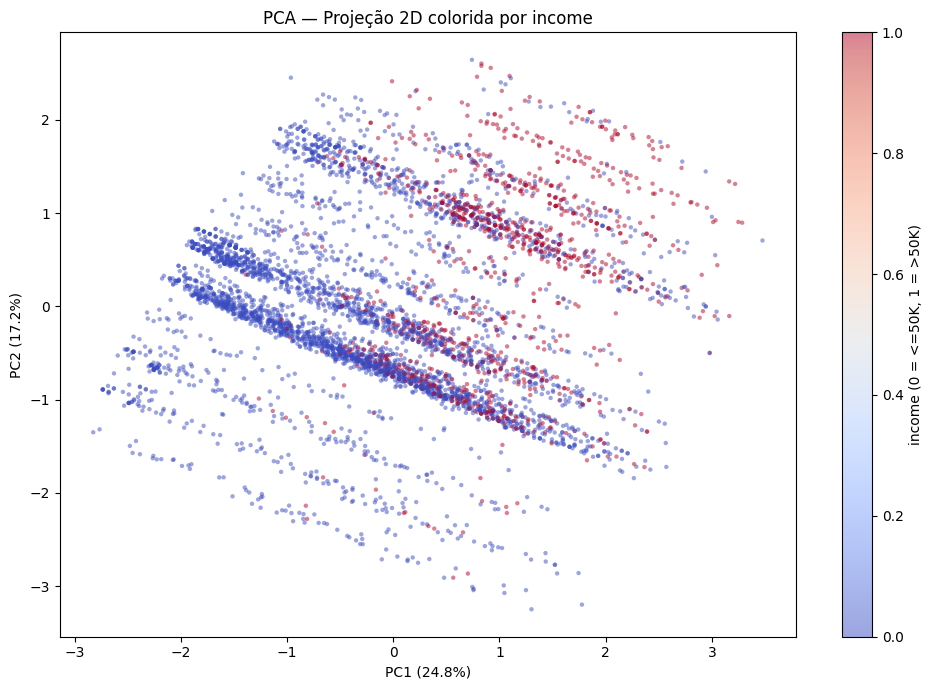

In [53]:
# Projeção PCA em 2D
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_small)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_small, cmap="coolwarm", alpha=0.5, s=10, edgecolors="none"
)
plt.colorbar(scatter, label="income (0 = <=50K, 1 = >50K)")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA — Projeção 2D colorida por income")
plt.tight_layout()
plt.show()

### t-SNE — t-Distributed Stochastic Neighbor Embedding

t-SNE é uma técnica **não linear** que preserva a estrutura local dos dados (vizinhos próximos permanecem próximos na projeção). Utiliza uma distribuição t-Student no espaço de baixa dimensão para resolver o *crowding problem*. O parâmetro `perplexity` controla o equilíbrio entre estrutura local e global — testamos dois valores para comparar.

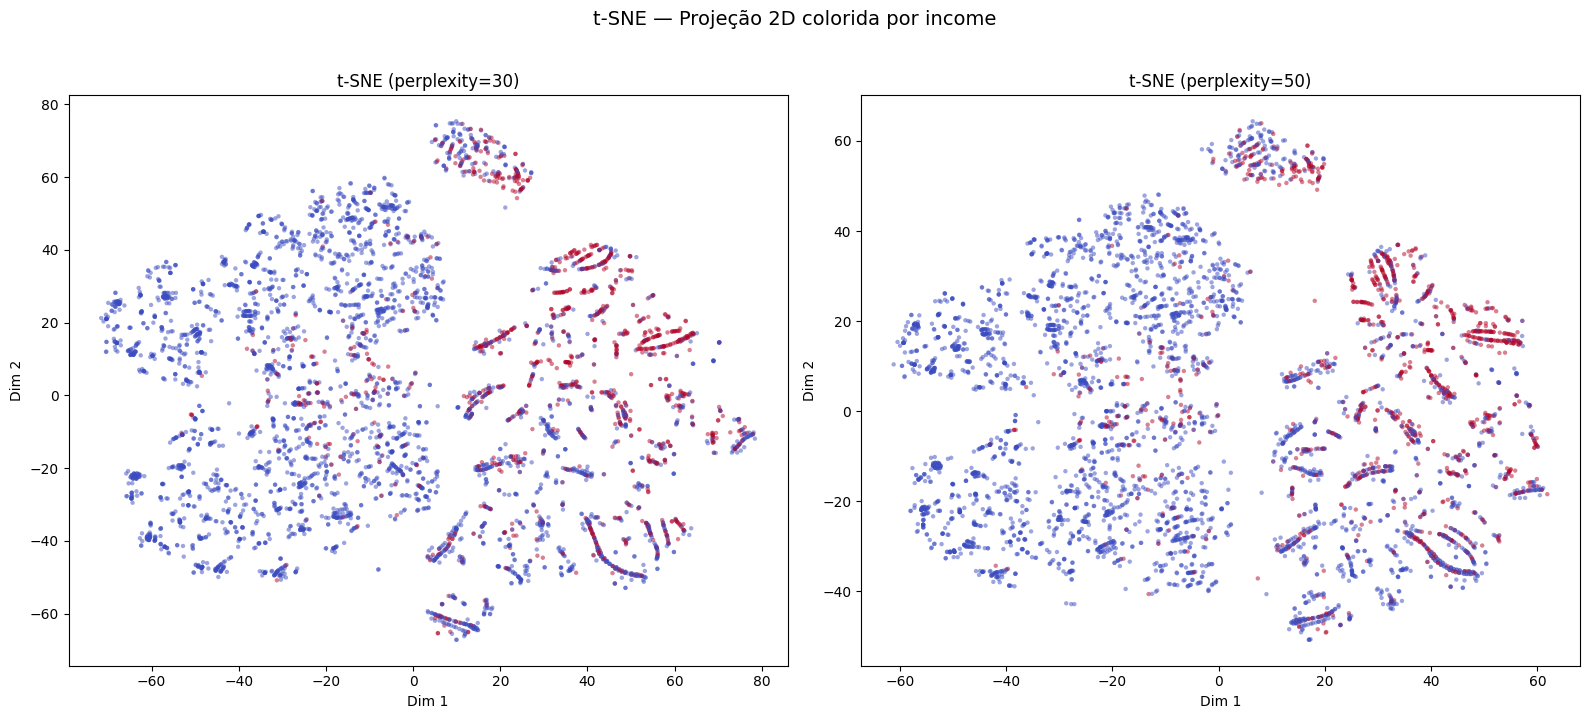

In [54]:
# t-SNE com duas perplexidades diferentes
perplexities = [30, 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_small)

    scatter = ax.scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c=y_small, cmap="coolwarm", alpha=0.5, s=10, edgecolors="none"
    )
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.suptitle("t-SNE — Projeção 2D colorida por income", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### UMAP — Uniform Manifold Approximation and Projection

UMAP é uma técnica não linear que preserva tanto a estrutura **local** quanto a **global** dos dados, sendo mais rápida e escalável que o t-SNE. O parâmetro `n_neighbors` controla o tamanho da vizinhança local e `min_dist` define o quão compactos os agrupamentos ficam.

/Users/guedes/Documents/Insper/Aulas26/MachineLearning/aulasMachineLearning/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/guedes/Documents/Insper/Aulas26/MachineLearning/aulasMachineLearning/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


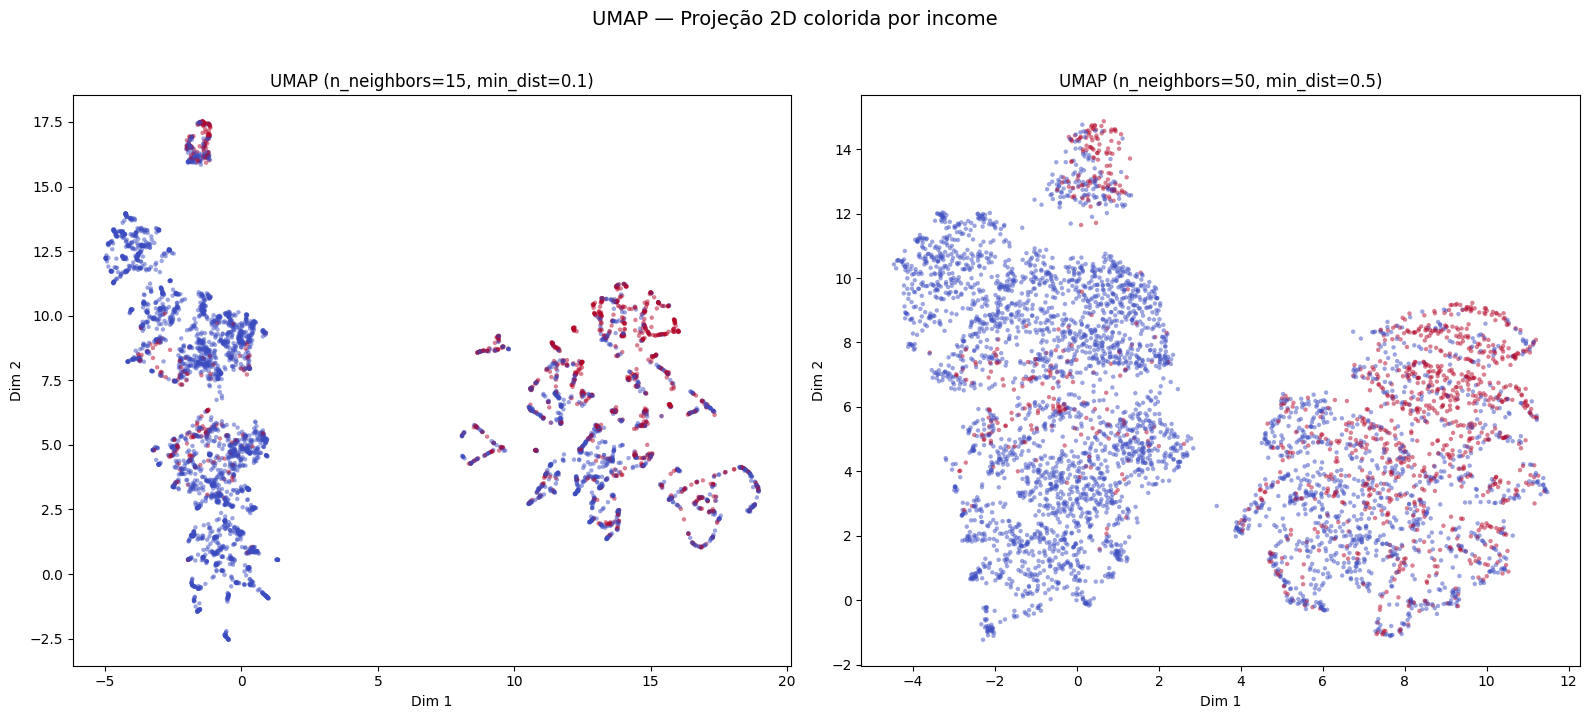

In [55]:
# UMAP com dois conjuntos de parâmetros
umap_params = [
    {"n_neighbors": 15, "min_dist": 0.1},
    {"n_neighbors": 50, "min_dist": 0.5},
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, params in zip(axes, umap_params):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=params["n_neighbors"],
        min_dist=params["min_dist"],
        random_state=42,
    )
    X_umap = reducer.fit_transform(X_small)

    scatter = ax.scatter(
        X_umap[:, 0], X_umap[:, 1],
        c=y_small, cmap="coolwarm", alpha=0.5, s=10, edgecolors="none"
    )
    ax.set_title(f"UMAP (n_neighbors={params['n_neighbors']}, min_dist={params['min_dist']})")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.suptitle("UMAP — Projeção 2D colorida por income", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Comparação: PCA vs t-SNE vs UMAP

/Users/guedes/Documents/Insper/Aulas26/MachineLearning/aulasMachineLearning/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


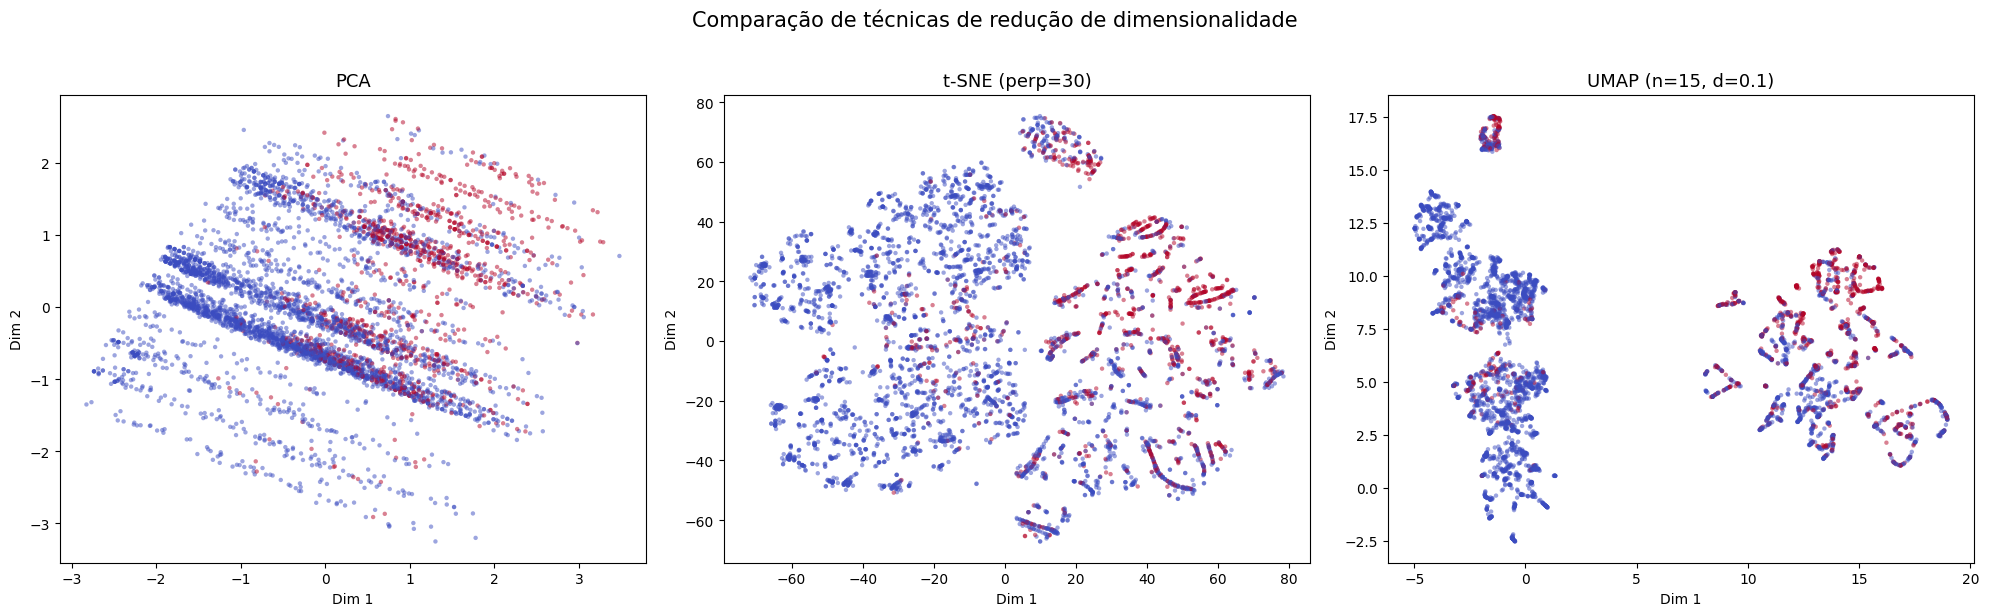

In [ ]:
# Comparação lado a lado: PCA, t-SNE e UMAP (melhores configurações)
pca_2d_cmp = PCA(n_components=2, random_state=42)
X_pca_cmp = pca_2d_cmp.fit_transform(X_small)

tsne_cmp = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne_cmp = tsne_cmp.fit_transform(X_small)

umap_cmp = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_cmp = umap_cmp.fit_transform(X_small)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ["PCA", "t-SNE (perp=30)", "UMAP (n=15, d=0.1)"]
projections = [X_pca_cmp, X_tsne_cmp, X_umap_cmp]

for ax, proj, title in zip(axes, projections, titles):
    scatter = ax.scatter(
        proj[:, 0], proj[:, 1],
        c=y_small, cmap="coolwarm", alpha=0.5, s=10, edgecolors="none"
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.suptitle("Comparação de técnicas de redução de dimensionalidade", fontsize=15, y=1.02)
plt.tight_layout()

#plota o gráfico comparativo
plt.show()

### Conclusões sobre a redução de dimensionalidade

- **PCA**: por ser linear, não consegue separar bem as duas classes de income em apenas 2 componentes. A variância explicada pelas primeiras componentes é relativamente baixa, indicando que a informação está distribuída por muitas dimensões (especialmente após o one-hot encoding). Ainda assim, é útil para compressão: poucas componentes já capturam a maior parte da variância total.

- **t-SNE**: revela agrupamentos locais mais definidos que o PCA. As duas classes de income se misturam consideravelmente, mas é possível identificar regiões com maior concentração de `>50K`. A variação da `perplexity` altera a granularidade dos clusters — valores menores evidenciam estrutura local mais fina, enquanto valores maiores suavizam a projeção.

- **UMAP**: apresenta resultados semelhantes ao t-SNE, mas com melhor preservação da estrutura global e execução mais rápida. Os agrupamentos tendem a ser mais coesos e as distâncias entre clusters mais interpretáveis.

De forma geral, a separação entre as classes `<=50K` e `>50K` não é trivial em 2D — há sobreposição significativa, o que reflete a complexidade do problema de classificação. As técnicas não lineares (t-SNE e UMAP) conseguem revelar sub-estruturas e padrões que o PCA não captura.